# Lab 1.5 — Dynamic pricing: one simple idea, five upgrades

Strip away the buzzwords and dynamic pricing is one sentence:

> **Re-solve the same simple question — "which price makes the most profit
> right now?" — every time the world changes.**

Everything else is deciding *what counts as the world changing*. This
notebook climbs that ladder one rung at a time (the track's ladder rule:
each level = the previous level + exactly one new complication):

| Level | The world changes because… | The tool |
|---|---|---|
| 0 | it doesn't — one price forever | a profit curve and a grid search |
| 1 | demand differs by day | the same grid search, run daily |
| 2 | you don't *know* the demand curve | learn while selling (a bandit) |
| 3 | stock is limited | pace pricing (baby revenue management) |
| 4 | the competitor reacts | game rules, not just math |
| 5 | the business demands volume too | **profit optimisation with a sales constraint** |

**The setting** (same world as the rest of the track): a travel-money desk.
The average customer orders **£500 of euros**; our price is the **margin m
in percentage points** ([file 1.2](02_percentages_and_basis_points.md)), so we earn **£5 per order per point of
margin**, and each order costs **£1** to handle. Profit per order = 5m − 1.
Note the built-in floor: at m = 0.2 an order earns exactly £0.

Each passing customer buys with probability that falls as margin rises:

> chance of buying = 0.7 × e^(−b × m)

One number, **b**, is the price sensitivity — big b, twitchy customers
([file 1.3](03_elasticity.md) in different clothes). ~1,000 customers walk past per day.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(11)

# Chart style: colour-blind-safe palette in fixed order, quiet grid, thin marks
C = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948"]
INK, SUB, MUT, GRID, AXIS = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": AXIS, "axes.labelcolor": SUB, "axes.titlecolor": INK,
    "xtick.color": MUT, "ytick.color": MUT,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "font.size": 11, "axes.titlesize": 12,
    "figure.figsize": (8, 4.2), "figure.dpi": 110, "legend.frameon": False,
})
def tidy(ax):
    ax.grid(axis="x", visible=False)

def buy_prob(m, b):          # chance a passing customer buys at margin m
    return 0.7 * np.exp(-b * m)

def day_profit(m, n, b):     # expected profit for one day: n customers, sensitivity b
    return n * buy_prob(m, b) * (5*m - 1)

M = np.arange(0.2, 4.01, 0.01)          # the margin grid we'll search, again and again

## Level 0 — static: one price, chosen properly

No cleverness. Compute expected profit at every margin on a grid and pick
the top. With b = 0.6, watch two things in the picture:

1. where the peak is, and
2. **how flat the curve is near the peak** — the most underrated fact in
   pricing. Being 25bp off the perfect price costs about 1%. This is why
   grown-up pricing worries more about being *confidently roughly right*
   than precisely optimal, and why guardrails beat heroics.

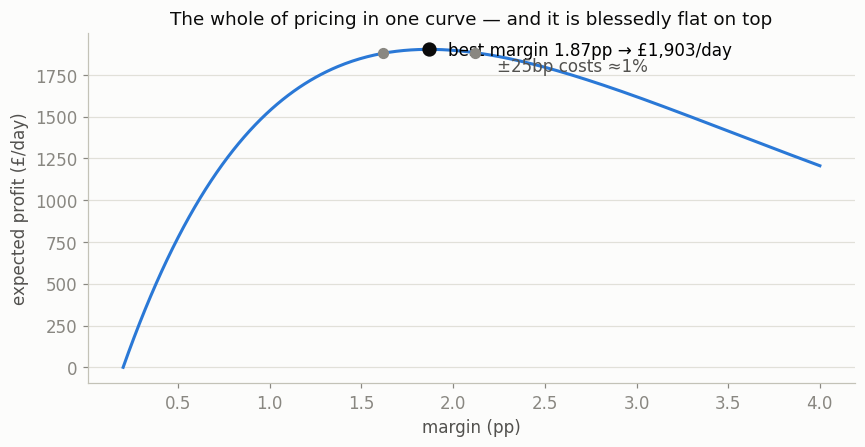

Check vs calculus: optimum should be 1/b + 0.2 = 1.87pp. Grid found 1.87pp.


In [2]:
b0, n0 = 0.6, 1000
profit = day_profit(M, n0, b0)
m_star = M[profit.argmax()]

fig, ax = plt.subplots()
ax.plot(M, profit, color=C[0])
ax.scatter([m_star], [profit.max()], s=70, color=INK, zorder=3)
ax.annotate(f"best margin {m_star:.2f}pp → £{profit.max():,.0f}/day",
            (m_star, profit.max()), xytext=(12, -4), textcoords="offset points")
for off in (-0.25, 0.25):
    p = day_profit(m_star + off, n0, b0)
    ax.scatter([m_star + off], [p], s=40, color=MUT, zorder=3)
ax.annotate("±25bp costs ≈1%", (m_star + 0.3, day_profit(m_star + 0.25, n0, b0)),
            color=SUB, xytext=(8, -12), textcoords="offset points")
ax.set_xlabel("margin (pp)"); ax.set_ylabel("expected profit (£/day)")
ax.set_title("The whole of pricing in one curve — and it is blessedly flat on top")
tidy(ax); plt.tight_layout(); plt.show()

print(f"Check vs calculus: optimum should be 1/b + 0.2 = {1/b0 + 0.2:.2f}pp. Grid found {m_star:.2f}pp.")

(That closed-form check, m* = 1/b + 0.2, is the exponential-demand cousin of
the classic markup rule from [file 1.3](03_elasticity.md): *optimal margin = one over sensitivity,
plus enough to recover cost*. You never need it — the grid search is the
method — but it's a good sanity check and a good interview line.)

## Level 1 — the world changes on a schedule

First complication: weekdays and weekends are different planets. Weekday
customers are locals comparing rates on their phones (b = 0.8, ~800 pass
by); weekend customers are holidaymakers who fly tomorrow (b = 0.45, ~1,500
pass by).

Dynamic pricing, level 1, is nothing deeper than: **run Level 0's grid
search once per day type.** No machine learning. Just refusing to charge the
average of two different worlds.

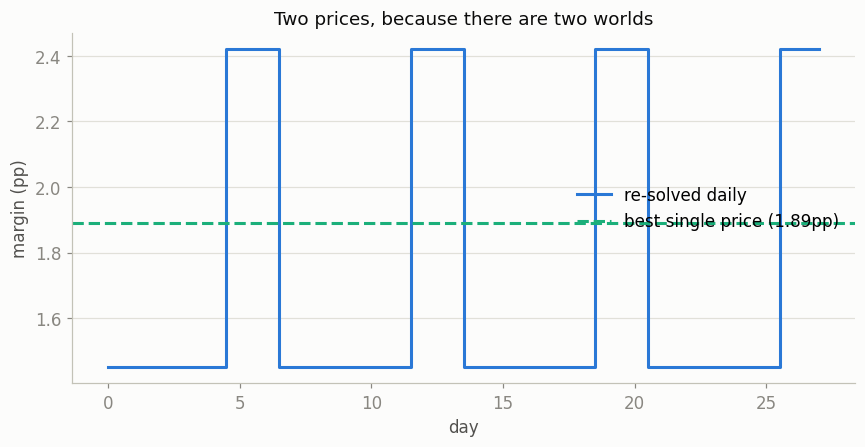

weekday price 1.45pp, weekend price 2.42pp
4-week profit: dynamic £53,324 vs one-price £51,188  →  +4.2%


In [3]:
days = pd.date_range("2026-01-05", periods=28, freq="D")     # four Mon–Sun weeks
weekend = days.dayofweek >= 5
n_day = np.where(weekend, 1500, 800)
b_day = np.where(weekend, 0.45, 0.8)

m_dyn = np.array([M[day_profit(M, n, b).argmax()] for n, b in zip(n_day, b_day)])
p_dyn = np.array([day_profit(m, n, b) for m, n, b in zip(m_dyn, n_day, b_day)])

# the best you can do with ONE price for all 28 days
total_by_m = [sum(day_profit(m, n, b) for n, b in zip(n_day, b_day)) for m in M]
m_flat = M[np.argmax(total_by_m)]
p_flat = np.array([day_profit(m_flat, n, b) for n, b in zip(n_day, b_day)])

fig, ax = plt.subplots()
ax.step(range(28), m_dyn, where="mid", color=C[0], label="re-solved daily")
ax.axhline(m_flat, color=C[1], linestyle="--", label=f"best single price ({m_flat:.2f}pp)")
ax.set_xlabel("day"); ax.set_ylabel("margin (pp)")
ax.set_title("Two prices, because there are two worlds")
ax.legend(); tidy(ax); plt.tight_layout(); plt.show()

uplift = p_dyn.sum()/p_flat.sum() - 1
print(f"weekday price {m_dyn[0]:.2f}pp, weekend price {m_dyn[5]:.2f}pp")
print(f"4-week profit: dynamic £{p_dyn.sum():,.0f} vs one-price £{p_flat.sum():,.0f}  →  +{uplift:.1%}")

A few percent for free, forever, from a two-row lookup table. Real desks
push the same idea further — hour of day, branch, season, pay-day — and each
split is still just Level 0 re-run inside a cell. **Most production "dynamic
pricing" is exactly this**, and it should be your default proposal: cheap,
explainable, auditable.

## Level 2 — you don't actually know b

Everything so far assumed we *know* the demand curve. We never do. Level 2:
the desk must **learn b while selling** — and every day spent charging an
exploratory price has a cost. This is the explore/exploit trade-off, and the
classic tool is a **bandit algorithm**.

The version below is Thompson sampling, which sounds fancy and is four lines:

1. Allow five candidate margins: 1.0, 1.5, 2.0, 2.5, 3.0.
2. For each, keep a running belief about its conversion rate (a Beta
   distribution: just "successes and failures so far").
3. Each morning, take one random *plausible* value from each belief, and
   charge the margin whose sampled value promises the most profit.
4. At close of business, update that margin's tally. Repeat.

Early on, beliefs are wide, so the desk naturally tries things. As evidence
piles up, beliefs narrow and it settles. Nobody schedules the exploration —
uncertainty itself does.

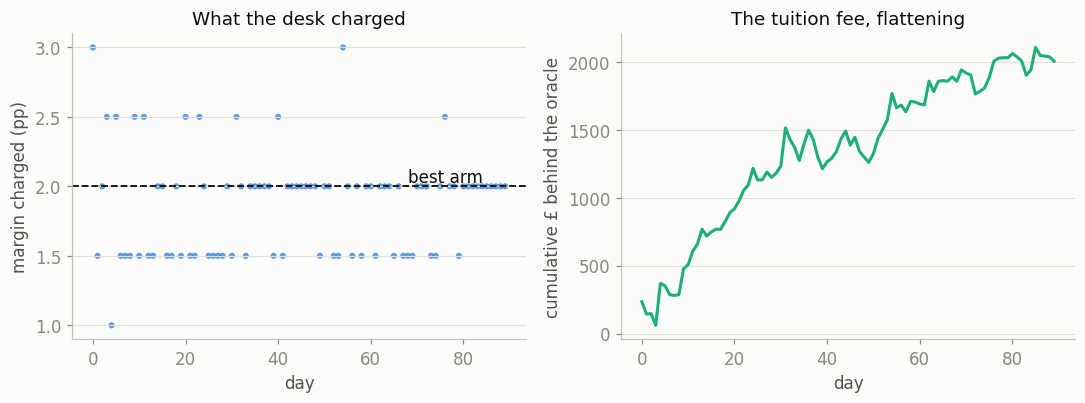

total learning cost over 90 days: £2,006 (vs £85,389 a perfect-knowledge desk would earn)


In [4]:
arms = np.array([1.0, 1.5, 2.0, 2.5, 3.0])
value = 5*arms - 1                              # £ per order at each margin
p_true = buy_prob(arms, b0)                     # hidden truth (b = 0.6)
oracle = 500 * (p_true * value).max()           # perfect-knowledge profit/day

wins = np.ones(5); losses = np.ones(5)          # our beliefs (Beta priors)
chosen, gap = [], []
for day in range(90):
    belief = rng.beta(wins, losses)             # one plausible conversion per arm
    a = int(np.argmax(belief * value))          # most promising arm this morning
    buys = rng.binomial(500, p_true[a])         # 500 customers face that price
    wins[a] += buys; losses[a] += 500 - buys
    chosen.append(arms[a]); gap.append(oracle - buys*value[a])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))
ax1.scatter(range(90), chosen, s=16, color=C[0], alpha=0.75, edgecolors="none")
ax1.axhline(arms[(p_true*value).argmax()], color=INK, linestyle="--", linewidth=1.2)
ax1.annotate("best arm", (68, arms[(p_true*value).argmax()]), va="bottom", color=INK)
ax1.set_xlabel("day"); ax1.set_ylabel("margin charged (pp)"); ax1.set_yticks(arms)
ax1.set_title("What the desk charged"); tidy(ax1)
ax2.plot(np.cumsum(gap), color=C[1])
ax2.set_xlabel("day"); ax2.set_ylabel("cumulative £ behind the oracle")
ax2.set_title("The tuition fee, flattening"); tidy(ax2)
plt.tight_layout(); plt.show()

print(f"total learning cost over 90 days: £{sum(gap):,.0f} "
      f"(vs £{90*oracle:,.0f} a perfect-knowledge desk would earn)")

Two honest observations:

- The desk keeps flickering between 1.5 and 2.0. **Not a bug.** Those two
  margins are nearly equally profitable, so telling them apart is expensive
  and barely worth it. The regret curve — money left on the table — is what
  matters, and it goes flat.
- In regulated retail money you cannot explore on customers arbitrarily
  (price fairness, Consumer Duty — [file 4.1](../04_satisfy_the_regulator/01_segments_and_fairness.md)). Real desks cap the exploration
  range, exclude vulnerable segments, and log every price served:
  [N9](../05_the_panel/N9_safe_exploration_consumer_duty.ipynb) is this level
  grown up.

## Level 3 — limited stock: price becomes a rationing tool

New complication: the desk holds **€1.5m of stock — 3,000 orders' worth —
for the 28 days**, and cannot restock. At Level 1's prices, customers would
happily buy ~6,300 orders. Someone must be turned away. The only question is
*who* — and price is how you choose.

If you ignore stock, you sell cheerfully for two weeks and then stand behind
an empty till during the best weekends ([file 2.4](../02_prove_the_change/04_forecasting_and_stockouts.md): the till never records the
customer who walked away).

The fix is embarrassingly simple — **pace pricing**:

> Each morning: pace = stock left ÷ days left. Charge the margin at which
> expected demand equals the pace.

Selling faster than pace? Prices drift up. Slower? They drift down. This is
baby revenue management — airlines run this exact logic with the word
"bid price" attached.

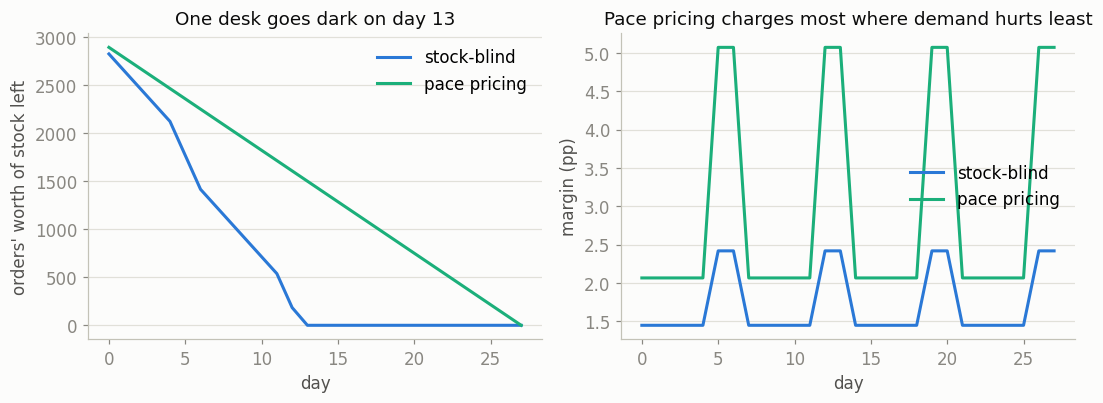

4-week profit on the SAME 3,000 orders of stock:
  stock-blind : £24,786
  pace pricing: £40,886   (+65%)


In [5]:
STOCK = 3000

def simulate(policy):
    left, ms, stock_path, profit = STOCK, [], [], 0.0
    for t in range(28):
        n, b = n_day[t], b_day[t]
        if policy == "stock-blind":
            m = m_dyn[t]                                  # Level 1 prices, ignore stock
        else:                                             # pace pricing
            pace = left / (28 - t)
            m = np.clip(np.log(0.7*n/pace)/b, 0.5, 6.0) if pace > 0.5 else 6.0
        q = min(n * buy_prob(m, b), left)                 # can't sell stock you don't have
        profit += q * (5*m - 1); left -= q
        ms.append(m); stock_path.append(left)
    return np.array(ms), np.array(stock_path), profit

m_blind, s_blind, prof_blind = simulate("stock-blind")
m_pace,  s_pace,  prof_pace  = simulate("pace")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))
ax1.plot(range(28), s_blind, color=C[0], label="stock-blind")
ax1.plot(range(28), s_pace,  color=C[1], label="pace pricing")
ax1.set_xlabel("day"); ax1.set_ylabel("orders' worth of stock left")
ax1.set_title("One desk goes dark on day "
              f"{int(np.argmax(s_blind < 1))}"); ax1.legend(); tidy(ax1)
ax2.plot(range(28), m_blind, color=C[0], label="stock-blind")
ax2.plot(range(28), m_pace,  color=C[1], label="pace pricing")
ax2.set_xlabel("day"); ax2.set_ylabel("margin (pp)")
ax2.set_title("Pace pricing charges most where demand hurts least")
ax2.legend(); tidy(ax2)
plt.tight_layout(); plt.show()

print(f"4-week profit on the SAME 3,000 orders of stock:")
print(f"  stock-blind : £{prof_blind:,.0f}")
print(f"  pace pricing: £{prof_pace:,.0f}   (+{prof_pace/prof_blind-1:.0%})")

Same stock, two-thirds more profit — with no extra information, just the
discipline of asking "what is a unit of stock *worth to me later* before I
sell it now?" That worth is called the **shadow price** of stock. Hold that
phrase; it is the key to Level 5.

Notice *where* pace pricing puts the pain: weekend margins soar (the
insensitive holidaymakers barely flinch), weekday margins rise far less.
Scarce stock is rationed by charging most where customers are least
price-sensitive — elasticity ([file 1.3](03_elasticity.md)) deciding who gets told no.

## Level 4 — the competitor reacts: rules beat reflexes

Final technical complication, and it isn't math — it's game theory
([file 1.5](05_competition.md)). Suppose both we and the rival desk run the same innocent
algorithm: **"if the other is cheaper, undercut them by 0.1pp."** A new
rival opens with a launch offer of 1.9pp. Watch what two tidy little
algorithms do to an industry — remember, at 0.2pp an order earns £0.

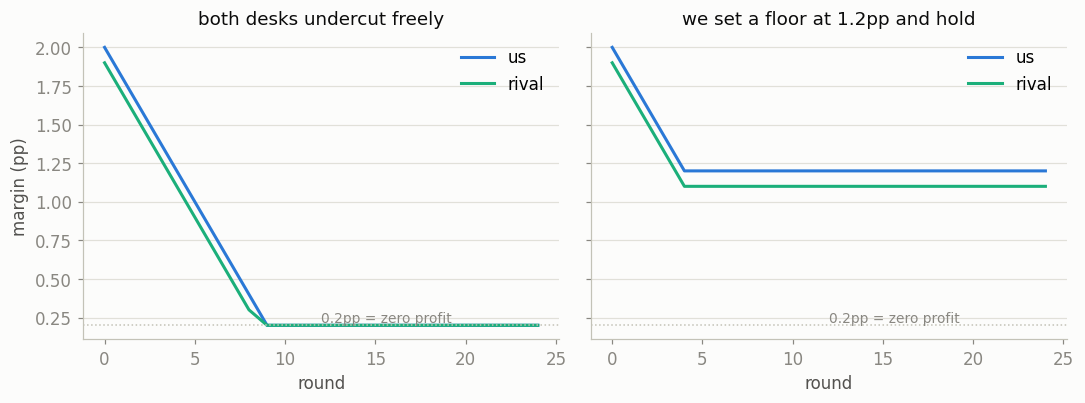

In [6]:
def price_war(our_floor):
    us, them = [2.0], [1.9]                       # their launch offer fires the gun
    for _ in range(24):
        nxt_us = max(them[-1] - 0.1, our_floor) if them[-1] < us[-1] else us[-1]
        us.append(nxt_us)
        nxt_them = max(us[-1] - 0.1, 0.2) if us[-1] < them[-1] else them[-1]
        them.append(nxt_them)
    return us, them

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, floor, title in [(axes[0], 0.2, "both desks undercut freely"),
                         (axes[1], 1.2, "we set a floor at 1.2pp and hold")]:
    us, them = price_war(floor)
    ax.plot(us, color=C[0], label="us")
    ax.plot(them, color=C[1], label="rival")
    ax.axhline(0.2, color=AXIS, linewidth=1, linestyle=":")
    ax.annotate("0.2pp = zero profit", (12, 0.22), color=MUT, fontsize=9)
    ax.set_xlabel("round"); ax.set_title(title); ax.legend(); tidy(ax)
axes[0].set_ylabel("margin (pp)")
plt.tight_layout(); plt.show()

Left panel: two profitable desks race each other to £0 per order in twenty
moves, and no human decided to do it. Automated repricing doesn't just make
mistakes — it makes them *fast*. Right panel: one rule change — **a floor,
below which we simply stop following** — and the spiral dies. The rival
parks 0.1pp below our floor; we keep every customer who isn't purely
price-driven.

And which customers are those? **[Lab 2.6](../02_prove_the_change/lab_06_causality_segments_competition.ipynb) already told you**: the
competitor-sensitivity γ was +0.1 at the Airport, +1.2 Online. So the
grown-up policy is segment-aware: contest the Online traffic, hold your
price at the Airport, and never automate a response you wouldn't sign off
manually — [N8](../05_the_panel/N8_competitor_response_game.ipynb) plays the
full game.

## Level 5 — profit optimisation with sales as a constraint

Now the complication is *organisational*. The sales director walks in:

> "Your optimal margin only does ~1,600 orders a week. Below **2,200 a
> week** the branch network stops making sense. I need volume."

This is the most common real-world pricing problem there is:

> **maximise profit(m), subject to volume(m) ≥ target.**

Because volume falls as margin rises, the constraint is really a **price
ceiling**: there is some margin m̄ at which volume exactly equals the
target, and you may not price above it. So the answer is one line:

> charge **min(m\*, m̄)** — your unconstrained optimum, unless the volume
> target caps you first.

No new machinery — the profit curve from Level 0 does all the work. What
*is* new is the negotiation, and one number wins it: the **shadow price of
the target** — the profit given up per extra order the target forces. Watch
for it below.

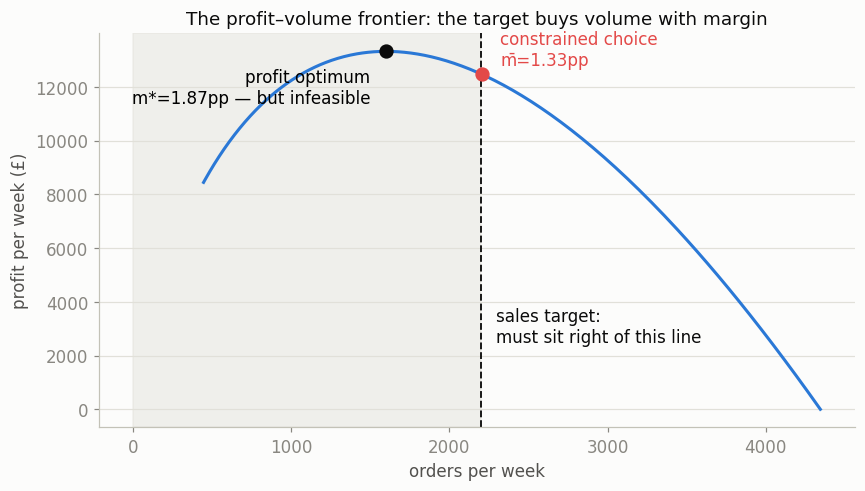

unconstrained: margin 1.87pp → 1,596 orders, £13,323/week
with target  : margin 1.33pp → 2,206 orders, £12,465/week
the target costs £858/week in total — and £2.64 per marginal forced order


In [7]:
week_vol    = 7 * n0 * buy_prob(M, b0)          # weekly orders at each margin
week_profit = week_vol * (5*M - 1)              # weekly profit at each margin
TARGET = 2200

i_star = week_profit.argmax()                                   # unconstrained optimum
feas   = np.where(week_vol >= TARGET, week_profit, -np.inf)
i_con  = feas.argmax()                                          # best feasible margin

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(week_vol, week_profit, color=C[0])
ax.axvspan(0, TARGET, color=GRID, alpha=0.45)
ax.axvline(TARGET, color=INK, linewidth=1.2, linestyle="--")
ax.annotate("sales target:\nmust sit right of this line", (TARGET, 2500),
            xytext=(10, 0), textcoords="offset points", color=INK)
ax.scatter(week_vol[i_star], week_profit[i_star], s=70, color=INK, zorder=3)
ax.annotate(f"profit optimum\nm*={M[i_star]:.2f}pp — but infeasible",
            (week_vol[i_star], week_profit[i_star]),
            xytext=(-10, -34), textcoords="offset points", ha="right")
ax.scatter(week_vol[i_con], week_profit[i_con], s=70, color=C[5], zorder=3)
ax.annotate(f"constrained choice\nm̄={M[i_con]:.2f}pp",
            (week_vol[i_con], week_profit[i_con]),
            xytext=(12, 6), textcoords="offset points", color=C[5])
ax.set_xlabel("orders per week"); ax.set_ylabel("profit per week (£)")
ax.set_title("The profit–volume frontier: the target buys volume with margin")
tidy(ax); plt.tight_layout(); plt.show()

cost = week_profit[i_star] - week_profit[i_con]
# shadow price: re-solve with the target nudged by ±100 orders and difference the profits
# (a nudge much wider than the grid's volume steps, so the answer doesn't snap to the grid)
def best_profit(target):
    return np.where(week_vol >= target, week_profit, -np.inf).max()
shadow = (best_profit(TARGET - 100) - best_profit(TARGET + 100)) / 200

print(f"unconstrained: margin {M[i_star]:.2f}pp → {week_vol[i_star]:,.0f} orders, £{week_profit[i_star]:,.0f}/week")
print(f"with target  : margin {M[i_con]:.2f}pp → {week_vol[i_con]:,.0f} orders, £{week_profit[i_con]:,.0f}/week")
print(f"the target costs £{cost:,.0f}/week in total — and £{shadow:.2f} per marginal forced order")

### How to think about it (and say it in the meeting)

- **The constraint is a purchase.** The desk is *buying* ~600 extra weekly
  orders and *paying* in margin. Total bill ≈ £850/week; the last order
  bought costs ≈ £2.70. Neither number is an opinion — they fall out of the
  demand curve.
- **The shadow price turns a shouting match into a decision.** "Is a
  marginal order worth £2.70 to us in cross-sell, market share and branch
  viability?" If yes, the target is cheap — approve it. If no, negotiate the
  target down, and you can now say exactly what each notch is worth.
- **The Lagrangian view** (one sentence for interviews): a volume constraint
  with shadow price λ is *identical* to unconstrained pricing where every
  order is worth £λ extra — the target quietly redefines your economics,
  as if handling cost fell from £1 to £(1 − λ).
- **You've already met the mirror image.** Level 3's stock limit was the
  same problem with the inequality flipped — volume ≤ stock — and its
  shadow price (the bid price) *raised* the effective bar instead. One
  framework covers both: **all of revenue management is profit maximisation
  plus shadow prices on constraints.** The repo's
  [lab_03_price_optimisation.ipynb](lab_03_price_optimisation.ipynb) runs this with
  scipy on a fitted model instead of a toy curve.

Practical guardrails before you ship a volume-constrained price: check the
constrained margin still clears cost-to-serve on every *segment* ([file 4.1](../04_satisfy_the_regulator/01_segments_and_fairness.md) and [lab 2.6](../02_prove_the_change/lab_06_causality_segments_competition.ipynb) — the average can hide a segment priced below water), and re-solve
when the demand curve moves — a constraint that was cheap in January can be
ruinous by June.

## The 60-second summary (say it out loud)

> "Dynamic pricing is re-solving a simple profit maximisation whenever the
> world changes. The ladder of 'what changes' goes: calendar (re-solve per
> day — that's most production systems), knowledge (bandits that learn the
> curve while respecting fairness guardrails), stock (pace pricing —
> scarcity gets a shadow price), and the competitor (respond by rule, with
> floors, or two algorithms will automate a price war). And when the
> business adds a sales target, nothing breaks: the target becomes a price
> ceiling, you charge min(m*, m̄), and the shadow price tells you exactly
> what the target costs per order — which is the number that decides the
> meeting."

## Where this goes in the repo — the ladder

| Rung | Where | What gets added |
|---|---|---|
| The profit curve, elasticity | files [1.1](01_price_cost_and_profit.md) and [1.3](03_elasticity.md) | the foundations |
| Price wars | file [1.5](05_competition.md) | why floors exist |
| Stockouts corrupt data | file [2.4](../02_prove_the_change/04_forecasting_and_stockouts.md) | censored demand |
| Full dynamic pricing sim | [engine/dynamic_pricing.py](../engine/dynamic_pricing.py) | causal model in the loop |
| Constrained optimisation, scipy | [lab_03_price_optimisation.ipynb](lab_03_price_optimisation.ipynb) | the production version of Level 5 |
| Safe exploration | [N9](../05_the_panel/N9_safe_exploration_consumer_duty.ipynb) | Level 2 under Consumer Duty |
| Competitor game, properly | [N8](../05_the_panel/N8_competitor_response_game.ipynb) | matched controls, response menus |

## Practice (try before peeking)

1. Level 3 sent weekend margins to ~5pp but weekday margins only to ~2pp.
   Why does the *scarce* desk charge most on exactly the days it has the
   most customers?
2. Your Level 2 bandit has spent 90 days and still hasn't "decided" between
   1.5pp and 2.0pp. Your boss calls it broken. Is it?
3. The sales director offers to drop the target from 2,200 to 2,000 orders
   if marketing gets the saved money. Using the shadow price idea, what is
   that concession roughly worth per week?

<details><summary>Answers</summary>

1. Rationing by price extracts the most money per turned-away customer where
   demand is least price-sensitive. Weekend holidaymakers (b = 0.45) barely
   reduce their buying when margin rises, so the desk can throttle demand to
   pace while collecting far more per order. Charging weekdays 5pp instead
   would vaporise the price-sensitive locals and leave stock unsold.
2. No. The two arms are within ~2% of each other in expected profit, so the
   *cost of not knowing* is tiny — and that cost (regret), not identifying
   the single best arm, is the objective. Spending weeks of lost profit to
   resolve a £20/day question would be the actual malfunction.
3. Roughly shadow price × orders: about £2.70 × 200 ≈ £550/week (slightly
   less in truth, since the shadow price shrinks as the target loosens —
   re-run `best_profit` at both targets for the exact figure).

</details>